In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from pathlib import Path

from going_modular.going_modular import utils, engine, data_setup, download_data

d:\Work\Coding\Machine-Learning\PyTorch\going_modular\going_modular\engine.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Device agnostic code

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Download data

In [3]:
## As I have already downloaded data, I am not gonna download it
## but you can download it using the download_data() if you haven't downloaded it yet

## Creating datasets and dataloaders

In [4]:
## Dataset directory

dataset_dir = Path('datasets/pizza_steak_sushi')

train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'


## Create transform

IMG_SIZE = 224

manual_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

## create dataset

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader, test_dataloader, classes = data_setup.create_dataloaders(train_dir=train_dir,
                                                                           test_dir=test_dir,
                                                                           transform=manual_transform,
                                                                           batch_size=BATCH_SIZE,
                                                                           num_workers=NUM_WORKERS)

train_dataloader, test_dataloader, classes

(<torch.utils.data.dataloader.DataLoader at 0x17973fefc10>,
 ['pizza', 'steak', 'sushi'])

## Visualize a single image

torch.Size([3, 224, 224]) tensor(2)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

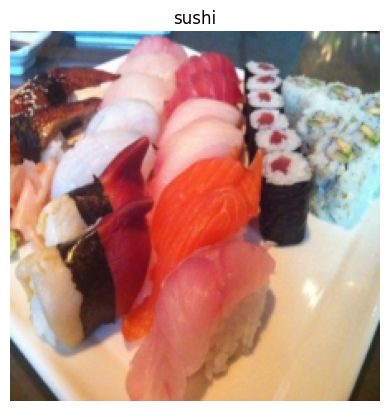

In [30]:
images, labels = next(iter(train_dataloader))

image = images[0]
label = labels[0]

print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

## Calculating the patch embedding input and output shape by hand

In [18]:
height = 224
width = 224
color_channels = 3
patch_size = 16

num_of_patches = int((height * width) / (pow(patch_size, 2)))
print(f"Number of patchs (N) with image (height={height} and width={width}) and (patch size={patch_size}): {num_of_patches}")

Number of patchs (N) with image (height=224 and width=224) and (patch size=16): 196


In [27]:
embedding_layer_input_shape =  (height, width, color_channels)
embedding_layer_output_shape = (num_of_patches, patch_size*patch_size*color_channels)

print(f"input shape (single 2d image): {embedding_layer_input_shape}")
print(f"output shape (single 2d image flattened into patches): {embedding_layer_output_shape}")

input shape (single 2d image): (224, 224, 3)
output shape (single 2d image flattened into patches): (196, 768)


torch.Size([3, 224, 224]) tensor(2)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

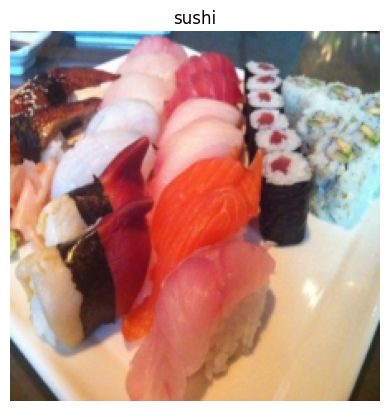

In [32]:
print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

## Let's visualize top row

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

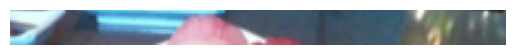

In [49]:
permuted_image = image.permute(1, 2, 0)

patch_size = 16

plt.imshow(permuted_image[:patch_size])
plt.axis(False)

## Now create patches for the top row

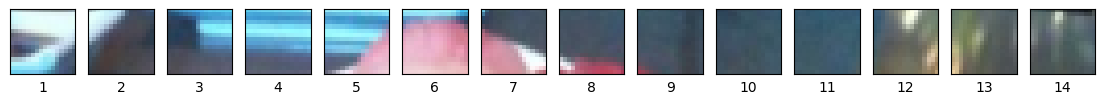

In [137]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows=1,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


start_iter_patch = 0
end_iter_patch = patch_size

for i in range(0, width//patch_size):

    axis[i].imshow(permuted_image[:patch_size, start_iter_patch: end_iter_patch, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    
    start_iter_patch += patch_size
    end_iter_patch += patch_size
    

## Create whole image patches

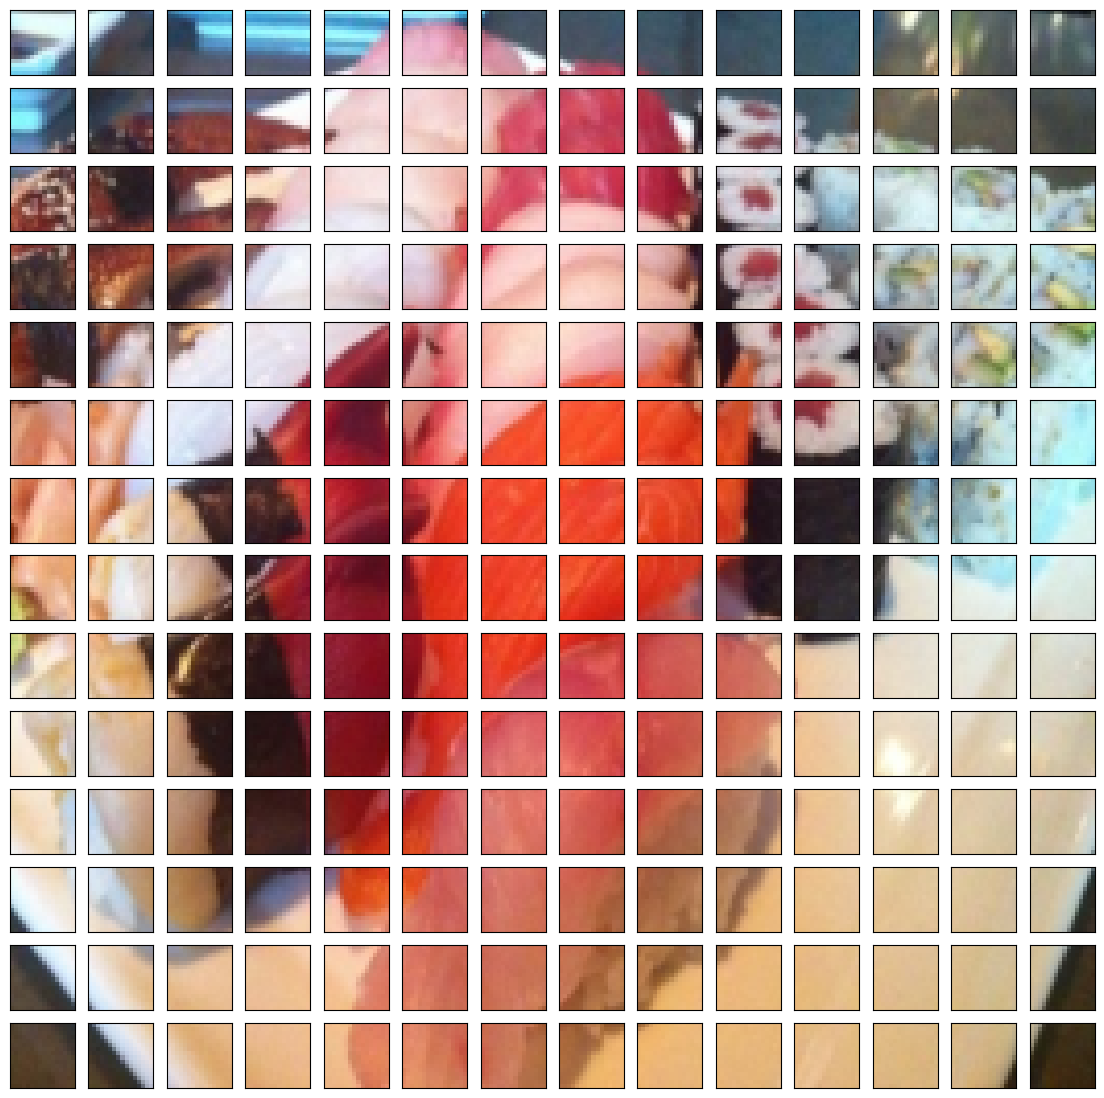

In [154]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows= height // patch_size,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


height_iter_patch = 0

for i in range(0, height//patch_size):

    width_iter_patch = 0

    for j in range(0, width//patch_size):

        axis[i, j].imshow(permuted_image[height_iter_patch:height_iter_patch+patch_size, width_iter_patch: width_iter_patch+patch_size, :])
        axis[i, j].set_xticks([])
        axis[i, j].set_yticks([])
        
        width_iter_patch += patch_size
    
    height_iter_patch += patch_size

In [142]:
height//patch_size

14